In [3]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

In [4]:
!wget --show-progress -O /tmp/test.safetensors https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors

--2026-07-14 06:44:42--  https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors
Resolving huggingface.co (huggingface.co)... 108.138.246.79, 108.138.246.85, 108.138.246.71, ...
Connecting to huggingface.co (huggingface.co)|108.138.246.79|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/621ffdc036468d709f174347/22f1240b5c3e6c4d5c19fe96c68b0600fca5743fba2460882dddac50aca607d8?user_id=public&X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27model.safetensors%3B+filename%3D%22model.safetensors%22%3B&Expires=1784015082&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjIxZmZkYzAzNjQ2OGQ3MDlmMTc0MzQ3LzIyZjEyNDBiNWMzZTZjNGQ1YzE5ZmU5NmM2OGIwNjAwZmNhNTc0M2ZiYTI0NjA4ODJkZGRhYzUwYWNhNjA3ZDhcXD91c2VyX2lkPXB1YmxpYyZYLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkVwb2No

In [5]:
!wget --show-progress -O /content/bert_tiny.bin \
  "https://huggingface.co/prajjwal1/bert-tiny/resolve/main/pytorch_model.bin?download=true"
!ls -lh /content/bert_tiny.bin

--2026-07-14 06:50:59--  https://huggingface.co/prajjwal1/bert-tiny/resolve/main/pytorch_model.bin?download=true
Resolving huggingface.co (huggingface.co)... 3.170.185.14, 3.170.185.35, 3.170.185.25, ...
Connecting to huggingface.co (huggingface.co)|3.170.185.14|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/621ffdc136468d709f17ef83/05526191ad0e4fa22e3d4fdb7160def3c04f6534de288d2795a40d105d3fb965?X-Xet-Cas-Uid=public&response-content-type=application%2Foctet-stream&user_id=public&response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27pytorch_model.bin%3B+filename%3D%22pytorch_model.bin%22%3B&Expires=1784015459&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjIxZmZkYzEzNjQ2OGQ3MDlmMTdlZjgzLzA1NTI2MTkxYWQwZTRmYTIyZTNkNGZkYjcxNjBkZWYzYzA0ZjY1MzRkZTI4OGQyNzk1YTQwZDEwNWQzZmI5NjVcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LXR5cGU9KiZ1c2VyX2lkPXB1YmxpYyZyZ

In [6]:
!wget --spider -S "https://huggingface.co/prajjwal1/bert-tiny/resolve/main/pytorch_model.bin?download=true" 2>&1 | tail -5

  Age: 9080
  Content-Security-Policy: default-src 'none'; media-src 'self'; sandbox allow-same-origin
Length: 17756393 (17M) [application/octet-stream]
Remote file exists.



In [7]:
!wget --show-progress -O /content/bert_tiny.bin \
  "https://huggingface.co/prajjwal1/bert-tiny/resolve/main/pytorch_model.bin?download=true"
!ls -lh /content/bert_tiny.bin

--2026-07-14 06:53:00--  https://huggingface.co/prajjwal1/bert-tiny/resolve/main/pytorch_model.bin?download=true
Resolving huggingface.co (huggingface.co)... 3.170.185.14, 3.170.185.35, 3.170.185.25, ...
Connecting to huggingface.co (huggingface.co)|3.170.185.14|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cas-bridge.xethub.hf.co/xet-bridge-us/621ffdc136468d709f17ef83/05526191ad0e4fa22e3d4fdb7160def3c04f6534de288d2795a40d105d3fb965?Expires=1784015580&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly9jYXMtYnJpZGdlLnhldGh1Yi5oZi5jby94ZXQtYnJpZGdlLXVzLzYyMWZmZGMxMzY0NjhkNzA5ZjE3ZWY4My8wNTUyNjE5MWFkMGU0ZmEyMmUzZDRmZGI3MTYwZGVmM2MwNGY2NTM0ZGUyODhkMjc5NWE0MGQxMDVkM2ZiOTY1KiIsIkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc4NDAxNTU4MH19fV19&Signature=MEYCIQCNExVqlVogje8HFnuDG4XEqOKkLl8WmLmBpoHXE95xVwIhAKtEpnM42bYlkMt%7EiGeZBExfupFXiuheM2Lwk-BR53pe&Key-Pair-Id=K3EPXBYC3CKDRZ&X-Xet-Cas-Uid=public&response-content-disposition=attachmen

In [8]:
import torch
from transformers import BertTokenizer, BertModel, BertConfig

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
config = BertConfig.from_pretrained("prajjwal1/bert-tiny", output_attentions=True)

model = BertModel(config)
state = torch.load("/content/bert_tiny.bin", map_location="cpu")
model.load_state_dict(state, strict=False)
model.eval()

sentence = "Ram told Shyam that he would win the match"
inputs = tokenizer(sentence, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

print("Tokens:", tokens)
print("Number of layers:", len(attentions))
print("Attention tensor shape per layer:", tuple(attentions[0].shape))

Tokens: ['[CLS]', 'ram', 'told', 'shy', '##am', 'that', 'he', 'would', 'win', 'the', 'match', '[SEP]']
Number of layers: 2
Attention tensor shape per layer: (1, 2, 12, 12)


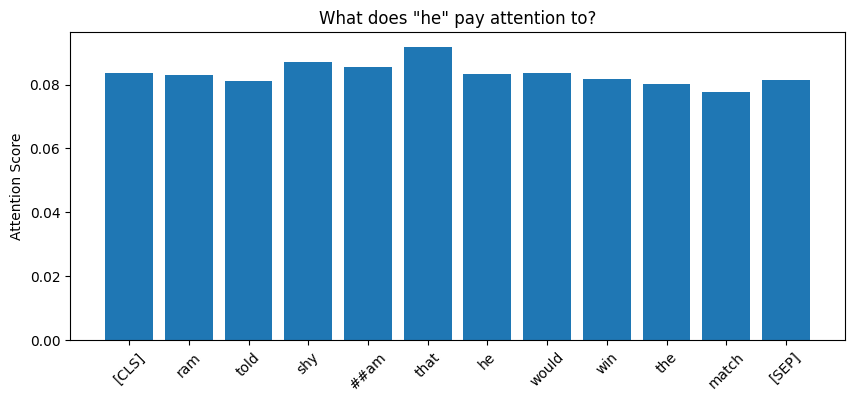

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Take attention from the last layer, first head
last_layer_attention = attentions[-1][0][0].numpy()

# Find position of the word "he" in tokens
he_index = tokens.index("he")

plt.figure(figsize=(10, 4))
plt.bar(tokens, last_layer_attention[he_index])
plt.title(f'What does "{tokens[he_index]}" pay attention to?')
plt.xticks(rotation=45)
plt.ylabel("Attention Score")
plt.show()